# Automated Calcaneal Inclination Angle (CIA) Measurement
### Multi-Structure Segmentation Pipeline

**This notebook has two independent sections:**

| Section | What you need | Which cells to run |
|---------|---------------|--------------------|
| **TRAIN** | Label Studio export JSON + X-ray images | Cells 1-2, Drive Mount, Core Algorithm, then TRAIN cells |
| **INFER** | Pre-trained `.pth` file + test images | Cells 1-2, Core Algorithm, then INFER cells |

Supported image formats: **PNG, JPEG, and DICOM (.dcm)**

**Runtime:** Go to `Runtime > Change runtime type > T4 GPU` before running.

---
**Method summary:**
Three anatomical structures are segmented simultaneously (U-Net + EfficientNet-B0):
- Calcaneus inferior surface → landmark P2 + tangent point P3
- 5th metatarsal head → landmark P1
- Calcaneocuboid joint → landmark P4

CIA = angle(P1→P2, P4→P3)

In [1]:
# =============================================================
# CELL 1 — INSTALL DEPENDENCIES
# =============================================================
!pip install segmentation-models-pytorch pydicom -q
print('Dependencies ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 47.7 MB/s eta 0:00:00
Dependencies ready.


In [2]:
# =============================================================
# CELL 2 — IMPORTS
# =============================================================
import os, json, random, warnings, hashlib
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


---
## Core Algorithm
Run this cell regardless of mode — it defines all functions.

In [3]:
# =============================================================
# CELL 5 — CORE ALGORITHM
# =============================================================

IMG_SIZE       = 512
POLYGON_LABELS = ['calcaneus_inferior', 'metatarsal_5', 'calcaneocuboid']
THRESHOLDS     = {
    'calcaneus_inferior': 0.50,
    'metatarsal_5':       0.33,
    'calcaneocuboid':  0.35,
}

# --- Preprocessing -------------------------------------------

def dicom_normalize(path):
    import pydicom
    ds = pydicom.dcmread(path, force=True)
    try:
        ds.decompress()
    except Exception:
        pass
    px = ds.pixel_array.astype(np.float32)
    if px.ndim == 3 and px.shape[2] >= 3:
        px = px[:, :, :3].mean(axis=2)
    if getattr(ds, 'PhotometricInterpretation', '') == 'MONOCHROME1':
        px = px.max() - px
    if hasattr(ds, 'WindowCenter') and hasattr(ds, 'WindowWidth'):
        wc = float(ds.WindowCenter[0] if hasattr(ds.WindowCenter, '__iter__') else ds.WindowCenter)
        ww = float(ds.WindowWidth[0]  if hasattr(ds.WindowWidth,  '__iter__') else ds.WindowWidth)
        px = np.clip(px, wc - ww / 2, wc + ww / 2)
    mn, mx = px.min(), px.max()
    if mx > mn:
        px = (px - mn) / (mx - mn) * 255.0
    img = px.astype(np.uint8)
    h = img.shape[0]
    img[:int(h * 0.08), :] = 0
    img[h - int(h * 0.06):, :] = 0
    return img


def _letterbox(img, size=IMG_SIZE):
    h, w = img.shape[:2]
    scale = min(size / h, size / w)
    nh, nw = int(h * scale), int(w * scale)
    ph, pw = (size - nh) // 2, (size - nw) // 2
    shape = (size, size) if img.ndim == 2 else (size, size, img.shape[2])
    out = np.zeros(shape, dtype=img.dtype)
    out[ph:ph + nh, pw:pw + nw] = cv2.resize(img, (nw, nh))
    return out, scale, ph, pw


# --- Label Studio parsing ------------------------------------

def _parse_task(task, images_dir):
    url = task.get('data', {}).get('image', '')
    # Handle Label Studio Local Storage URLs: /data/local-files/?d=filename.png
    if '?d=' in url:
        png = url.split('?d=')[-1].split('/')[-1]
    else:
        png = url.split('/')[-1]
    result = (task.get('annotations') or [{}])[0].get('result', [])
    if not result:
        return None
    orig_w = orig_h = None
    for r in result:
        if 'original_width' in r:
            orig_w, orig_h = r['original_width'], r['original_height']
            break
    if orig_w is None:
        img = cv2.imread(os.path.join(images_dir, png))
        if img is None:
            return None
        orig_h, orig_w = img.shape[:2]
    polygons = {}
    for r in result:
        if r['type'] == 'polygonlabels':
            for lbl in r['value'].get('polygonlabels', []):
                if lbl in POLYGON_LABELS:
                    polygons[lbl] = [
                        [p[0] / 100 * orig_w, p[1] / 100 * orig_h]
                        for p in r['value']['points']
                    ]
    if not polygons:
        return None
    return {'png': png, 'width': orig_w, 'height': orig_h, 'polygons': polygons}


def _save_mask(entry, mask_path):
    h, w = entry['height'], entry['width']
    mask = np.zeros((h, w, 3), dtype=np.uint8)
    for ch, lbl in enumerate(POLYGON_LABELS):
        if lbl in entry['polygons']:
            pts = np.array(entry['polygons'][lbl], dtype=np.int32)
            ch_mask = np.zeros((h, w), dtype=np.uint8)
            cv2.fillPoly(ch_mask, [pts], 255)
            mask[:, :, ch] = ch_mask
    cv2.imwrite(mask_path, mask)


def parse_ls_export(export_json, images_dir, masks_dir):
    os.makedirs(masks_dir, exist_ok=True)
    with open(export_json, encoding='utf-8') as f:
        ls_data = json.load(f)
    dataset = []
    for task in ls_data:
        entry = _parse_task(task, images_dir)
        if entry is None:
            continue
        if not os.path.exists(os.path.join(images_dir, entry['png'])):
            continue
        mask_name = entry['png'].replace('.png', '_mask.png')
        mask_path = os.path.join(masks_dir, mask_name)
        if not os.path.exists(mask_path):
            _save_mask(entry, mask_path)
        dataset.append({
            'png':             entry['png'],
            'mask':            mask_name,
            'width':           entry['width'],
            'height':          entry['height'],
            'has_calcaneus':   'calcaneus_inferior' in entry['polygons'],
            'has_metatarsal':  'metatarsal_5'       in entry['polygons'],
            'has_calcaneocuboid': 'calcaneocuboid'  in entry['polygons'],
        })
    return dataset


def patient_split(dataset, val_ratio=0.20, seed=42):
    random.seed(seed)
    groups = {}
    for d in dataset:
        pid = d['png'].split('__')[0]
        groups.setdefault(pid, []).append(d)
    keys = list(groups.keys())
    random.shuffle(keys)
    val_n = max(1, int(len(keys) * val_ratio))
    train, val = [], []
    for i, k in enumerate(keys):
        (val if i < val_n else train).extend(groups[k])
    return train, val


# --- Dataset -------------------------------------------------

class CalcaneusSegDataset(Dataset):
    def __init__(self, entries, images_dir, masks_dir, augment=False):
        self.entries    = entries
        self.images_dir = images_dir
        self.masks_dir  = masks_dir
        self.augment    = augment

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        e    = self.entries[idx]
        img  = cv2.imread(os.path.join(self.images_dir, e['png']),  cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(os.path.join(self.masks_dir,  e['mask']), cv2.IMREAD_COLOR)
        img  = img  if img  is not None else np.zeros((IMG_SIZE, IMG_SIZE),    np.uint8)
        mask = mask if mask is not None else np.zeros((IMG_SIZE, IMG_SIZE, 3), np.uint8)

        h0, w0 = img.shape[:2]
        scale  = min(IMG_SIZE / h0, IMG_SIZE / w0)
        nh, nw = int(h0 * scale), int(w0 * scale)
        ph, pw = (IMG_SIZE - nh) // 2, (IMG_SIZE - nw) // 2

        img_lb  = np.zeros((IMG_SIZE, IMG_SIZE),    np.uint8)
        mask_lb = np.zeros((IMG_SIZE, IMG_SIZE, 3), np.uint8)
        img_lb[ph:ph+nh, pw:pw+nw]  = cv2.resize(img,  (nw, nh))
        mask_lb[ph:ph+nh, pw:pw+nw] = cv2.resize(mask, (nw, nh),
                                                  interpolation=cv2.INTER_LINEAR)
        mask_lb = (mask_lb > 127).astype(np.uint8) * 255

        if self.augment and random.random() > 0.5:
            img_lb  = np.fliplr(img_lb).copy()
            mask_lb = np.fliplr(mask_lb).copy()

        valid  = np.array(
            [e['has_calcaneus'], e['has_metatarsal'], e['has_calcaneocuboid']],
            dtype=np.float32,
        )
        img_t  = torch.from_numpy(img_lb.astype(np.float32) / 255.0).unsqueeze(0)
        mask_t = torch.from_numpy((mask_lb > 127).astype(np.float32)).permute(2, 0, 1)
        return img_t, mask_t, torch.from_numpy(valid)


# --- Model & Loss --------------------------------------------

def build_model(weights=None):
    model = smp.Unet(
        encoder_name='efficientnet-b0',
        encoder_weights='imagenet' if weights is None else None,
        in_channels=1,
        classes=3,
        activation=None,
    ).to(DEVICE)
    if weights:
        model.load_state_dict(torch.load(weights, map_location=DEVICE))
    return model


class MaskedDiceBCELoss(nn.Module):
    CH_WEIGHTS = [1.0, 3.0, 5.0]  # calcaneus, metatarsal, calcaneocuboid

    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets, valid_mask):
        total, n_valid = 0.0, 0.0
        for ch in range(logits.shape[1]):
            vm = valid_mask[:, ch]
            if vm.sum() == 0:
                continue
            lg, tg = logits[vm > 0, ch], targets[vm > 0, ch]
            pos_r = tg.sum() / (tg.numel() + 1e-6)
            pos_w = torch.tensor([(1 - pos_r) / (pos_r + 1e-6)]).clamp(max=50).to(lg.device)
            bce   = F.binary_cross_entropy_with_logits(lg, tg, pos_weight=pos_w)
            p     = torch.sigmoid(lg).reshape(-1)
            t     = tg.reshape(-1)
            inter = (p * t).sum()
            dice  = (2 * inter + self.smooth) / (p.sum() + t.sum() + self.smooth)
            w       = self.CH_WEIGHTS[ch]
            total  += w * ((1 - dice) + bce)
            n_valid += w
        return total / max(n_valid, 1)


# --- Geometric landmark derivation ---------------------------

def _largest_contour(mask):
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not cnts:
        return None
    c = max(cnts, key=cv2.contourArea).squeeze(axis=1)
    if c.ndim == 1:
        c = c.reshape(-1, 2)
    return c.astype(np.float64)


def derive_P1(mask):
    c = _largest_contour(mask)
    return c[np.argmax(c[:, 1])] if c is not None else None


def derive_P2(mask):
    c = _largest_contour(mask)
    return c[np.argmax(c[:, 1])] if c is not None else None


def derive_P4(mask, flipped=False):
    c = _largest_contour(mask)
    if c is None:
        return None
    score = c[:, 1] - c[:, 0] if flipped else c[:, 0] + c[:, 1]
    return c[np.argmax(score)]


def extract_inferior_contour(mask, smooth_window=8, bin_size=3):
    c = _largest_contour((mask > 0).astype(np.uint8) * 255)
    if c is None or len(c) < 5:
        return None
    xs, ys = c[:, 0], c[:, 1]
    bins   = np.arange(xs.min(), xs.max() + bin_size, bin_size)
    inf    = []
    for i in range(len(bins) - 1):
        m = (xs >= bins[i]) & (xs < bins[i + 1])
        if m.any():
            idx = np.where(m)[0]
            inf.append(c[idx[np.argmax(ys[idx])]])
    if len(inf) < 3:
        return None
    inf = np.array(inf)[np.argsort(np.array(inf)[:, 0])]
    if smooth_window > 1 and len(inf) > smooth_window:
        k   = np.ones(smooth_window) / smooth_window
        inf = np.stack([
            np.convolve(inf[:, 0], k, 'valid'),
            np.convolve(inf[:, 1], k, 'valid'),
        ], axis=1)
    return inf


def lower_tangent(P4, contour, min_dist=10.0):
    P4  = np.asarray(P4, np.float64)
    far = contour[np.linalg.norm(contour - P4, axis=1) >= min_dist]
    if len(far) < 3:
        return None
    hull_idx = cv2.convexHull(far.astype(np.float32), returnPoints=False).reshape(-1)
    hull = far[hull_idx]
    n    = len(hull)
    if n < 3:
        return None
    candidates = []
    for i in range(n):
        V, Vp, Vn = hull[i], hull[(i - 1) % n], hull[(i + 1) % n]
        d = V - P4
        if np.linalg.norm(d) < 1e-6:
            continue
        sp = d[0] * (Vp[1] - V[1]) - d[1] * (Vp[0] - V[0])
        sn = d[0] * (Vn[1] - V[1]) - d[1] * (Vn[0] - V[0])
        if sp * sn >= -1e-6:
            candidates.append(V)
    if not candidates:
        return None
    cands = np.array(candidates)
    return cands[np.argmax(cands[:, 1])]


def compute_CIA(P1, P2, P3, P4):
    P1, P2, P3, P4 = (np.asarray(p, np.float64) for p in [P1, P2, P3, P4])
    vg    = P2 - P1
    vt    = P3 - P4
    cos_t = np.dot(vg, vt) / (np.linalg.norm(vg) * np.linalg.norm(vt) + 1e-10)
    angle = np.degrees(np.arccos(np.clip(cos_t, -1, 1)))
    return min(angle, 180 - angle)


# --- Inference -----------------------------------------------

def predict_masks(model, img_gray):
    h0, w0 = img_gray.shape
    img_lb, scale, ph, pw = _letterbox(img_gray)
    nh, nw = int(h0 * scale), int(w0 * scale)
    tensor = (torch.from_numpy(img_lb.astype(np.float32) / 255.0)
              .unsqueeze(0).unsqueeze(0).to(DEVICE))
    with torch.no_grad():
        probs = torch.sigmoid(model(tensor)).squeeze().cpu().numpy()
    masks = {}
    for ch, lbl in enumerate(POLYGON_LABELS):
        crop = probs[ch, ph:ph + nh, pw:pw + nw]
        full = cv2.resize(crop, (w0, h0), interpolation=cv2.INTER_LINEAR)
        masks[lbl] = (full > THRESHOLDS[lbl]).astype(np.uint8) * 255
    return masks


def full_inference(model, img_path, flipped=None):
    if img_path.lower().endswith('.dcm'):
        img_gray = dicom_normalize(img_path)
    else:
        img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        return None, {}, None, None, None, None, None
    if flipped is None:
        flipped = os.path.basename(img_path).lower().endswith('_flip.png')
    masks   = predict_masks(model, img_gray)
    P1      = derive_P1(masks['metatarsal_5'])
    P2      = derive_P2(masks['calcaneus_inferior'])
    P4      = derive_P4(masks['calcaneocuboid'], flipped=flipped)
    P3 = cia = None
    if all(p is not None for p in [P1, P2, P4]):
        contour = extract_inferior_contour(masks['calcaneus_inferior'])
        if contour is not None:
            P3 = lower_tangent(P4, contour)
            if P3 is not None:
                cia = compute_CIA(P1, P2, P3, P4)
    return cia, masks, img_gray, P1, P2, P3, P4


print('Core algorithm loaded.')

Core algorithm loaded.


---
## ANNOTATION GUIDE (Label Studio)
**Only needed if you want to train on your own data.**
Skip this entire section if you already have a Label Studio export JSON.

---

### Step 1 — Prepare your images

Create a folder on your Desktop (e.g. `xray_images`) and place all X-ray images inside it.
Supported formats: **PNG, JPEG, and DICOM (.dcm)**.

> **DICOM files?** Label Studio cannot display DICOM directly.
> Run the **DICOM-to-PNG Converter** cell (right after this guide) to convert them first.
> The converter reads PatientID from DICOM metadata and names files automatically.

**Filename convention** (required for patient-level train/val split):
```
<patient_id>__<anything>.png
```
Examples: `patient001__lateral.png`, `A0042__left_foot.png`

The double underscore `__` separates the patient ID from the rest of the filename.
The DICOM converter generates this format automatically.

---

### Step 2 — Install Label Studio (one-time setup)

Label Studio requires **Python 3.10 -- 3.12** (does not support 3.13+).
If you only have a newer version, install Python 3.12 from
[python.org/downloads](https://www.python.org/downloads/release/python-31210/).

**Open a terminal:**
- **Windows:** Press `Win + R`, type `cmd`, press Enter
- **macOS:** Open Terminal from Applications > Utilities
- **Linux:** Press `Ctrl + Alt + T`

Run these commands **one by one** in the terminal:

**Windows:**
```cmd
cd %USERPROFILE%\Desktop
py -3.12 -m venv ls_env
ls_env\Scripts\activate
pip install label-studio
```

**macOS / Linux:**
```bash
cd ~/Desktop
python3.12 -m venv ls_env
source ls_env/bin/activate
pip install label-studio
```

> This creates a `ls_env` folder on your Desktop. You only need to do this **once**.

---

### Step 3 — Start Label Studio

Every time you want to annotate, open a **new terminal** and run **all lines below** in order:

**Windows:**
```cmd
cd %USERPROFILE%\Desktop
ls_env\Scripts\activate
set LABEL_STUDIO_LOCAL_FILES_SERVING_ENABLED=true
set LABEL_STUDIO_LOCAL_FILES_DOCUMENT_ROOT=%USERPROFILE%\Desktop
label-studio start
```

**macOS / Linux:**
```bash
cd ~/Desktop
source ls_env/bin/activate
export LABEL_STUDIO_LOCAL_FILES_SERVING_ENABLED=true
export LABEL_STUDIO_LOCAL_FILES_DOCUMENT_ROOT=~/Desktop
label-studio start
```

Your browser will open **http://localhost:8080** automatically.
On first launch, create a local account (no internet required).

> **Note:** The DOCUMENT_ROOT is set to your Desktop folder.
> Your images folder (e.g. `xray_images`) must be **inside** it.

---

### Step 4 — Create a project and set the labeling config

1. Click **Create Project**, give it a name (e.g. "CIA Annotation")
2. Go to the **Labeling Setup** tab
3. Choose **Custom template**
4. Delete everything and paste this XML:

```xml
<View>
  <Header value="Calcaneal CIA Annotation" />
  <Image name="img" value="$image"
         zoom="true" zoomControl="true"
         brightnessControl="true" contrastControl="true" />
  <PolygonLabels name="poly" toName="img"
                 strokeWidth="3" pointSize="small" opacity="0.7">
    <Label value="calcaneus_inferior"  background="rgba(0,255,200,0.5)" />
    <Label value="metatarsal_5"        background="rgba(255,100,100,0.5)" />
    <Label value="calcaneocuboid"   background="rgba(100,150,255,0.5)" />
  </PolygonLabels>
</View>
```

5. Click **Save**

---

### Step 5 — Connect your images folder

1. Open your project and click **Settings** (gear icon, top-right)
2. Go to the **Cloud Storage** tab
3. Click **Add Source Storage**

**Page 1 -- Configure Connection:**
- Storage Type: **Local files**
- Absolute local path: full path to your images folder, e.g.:
  - Windows: `C:\Users\YourName\Desktop\xray_images`
  - macOS: `/Users/yourname/Desktop/xray_images`
- Click **Next**

> The path must be a subfolder of your Desktop (not equal to it).

**Page 2 -- Import Settings & Preview:**
- Import Method: click the **"All Tasks Files"** link below the dropdown
- File Name Filter: `.*\.(png|jpg|jpeg)$`
- You should see your images in the preview panel
- Click **Next**

**Page 3 -- Review & Confirm:**
- Click **Save & Sync**

All images will appear as annotation tasks in your project.

---

### Step 6 — Annotate

For each image, draw polygons around the visible structures:

| Color | Label | Structure |
|-------|-------|-----------|
| Cyan | `calcaneus_inferior` | Inferior surface of the calcaneus |
| Red | `metatarsal_5` | 5th metatarsal head |
| Blue | `calcaneocuboid` | Calcaneocuboid joint region |

Annotating **at least one** structure per image is sufficient.
The model uses per-channel masking, so partially annotated images still contribute to training.

---

### Step 7 — Export

1. Go to your project's main page
2. Click **Export**
3. Choose **JSON** format
4. Save the downloaded file -- upload it in CELL 6 below

---
## DICOM-to-PNG Converter (optional)
**Run this cell only if your images are in DICOM (.dcm) format.**
It converts all `.dcm` files in a folder to normalized PNG images.
The output filenames follow the `<PatientID>__<filename>.png` convention automatically.

In [ ]:
# =============================================================
# DICOM-to-PNG CONVERTER  (optional — skip if you already have PNGs)
# =============================================================
# Set DICOM_DIR to your folder of .dcm files.
# Converted PNGs will be saved to PNG_OUT_DIR.

DICOM_DIR   = '/content/drive/MyDrive/cia_data/dicoms'   # <-- edit this
PNG_OUT_DIR = '/content/drive/MyDrive/cia_data/images'    # <-- edit this

import pydicom, re, glob

os.makedirs(PNG_OUT_DIR, exist_ok=True)

dcm_files = sorted(glob.glob(os.path.join(DICOM_DIR, '**', '*.dcm'), recursive=True) +
                    glob.glob(os.path.join(DICOM_DIR, '**', '*.DCM'), recursive=True))

# Also find DICOM files without extension (common in medical imaging)
for f in sorted(glob.glob(os.path.join(DICOM_DIR, '**', '*'), recursive=True)):
    if os.path.isfile(f) and not os.path.splitext(f)[1]:
        try:
            pydicom.dcmread(f, stop_before_pixels=True, force=True)
            dcm_files.append(f)
        except Exception:
            pass

converted, skipped = 0, 0
for dcm_path in dcm_files:
    try:
        ds = pydicom.dcmread(dcm_path, force=True)

        # Extract PatientID from metadata (fall back to filename)
        patient_id = getattr(ds, 'PatientID', '').strip()
        if not patient_id:
            patient_id = os.path.splitext(os.path.basename(dcm_path))[0]
        # Clean non-alphanumeric characters
        patient_id = re.sub(r'[^a-zA-Z0-9_-]', '_', patient_id)

        # Build output filename: <PatientID>__<original_filename>.png
        stem = os.path.splitext(os.path.basename(dcm_path))[0]
        stem = re.sub(r'[^a-zA-Z0-9_-]', '_', stem)
        out_name = f'{patient_id}__{stem}.png'
        out_path = os.path.join(PNG_OUT_DIR, out_name)

        if os.path.exists(out_path):
            skipped += 1
            continue

        img = dicom_normalize(dcm_path)
        cv2.imwrite(out_path, img)
        converted += 1

    except Exception as e:
        print(f'  SKIP {os.path.basename(dcm_path)}: {e}')
        skipped += 1

total_png = len([f for f in os.listdir(PNG_OUT_DIR) if f.endswith('.png')])
print(f'Converted: {converted}  |  Skipped: {skipped}  |  Total PNGs in folder: {total_png}')
print(f'Output: {PNG_OUT_DIR}')

---
## TRAIN MODE
**Skip to INFER MODE if you only want to run inference.**

Run the cells below in order. Edit the paths in the config cell first.

In [ ]:
# =============================================================
# TRAIN CONFIG  (edit paths below)
# =============================================================
from google.colab import drive
drive.mount('/content/drive')

IMAGES_DIR  = '/content/drive/MyDrive/cia_data/images'   # X-ray PNGs on Drive
MASKS_DIR   = '/content/masks'                            # auto-created (temporary)
MODEL_OUT   = '/content/drive/MyDrive/cia_data/best_seg3ch.pth'
EPOCHS      = 60
BATCH_SIZE  = 8
LR          = 1e-3

print(f'Images : {IMAGES_DIR}')
print(f'Model  : {MODEL_OUT}')
print(f'Epochs : {EPOCHS}  Batch: {BATCH_SIZE}  LR: {LR}')

In [ ]:
# =============================================================
# UPLOAD LABEL STUDIO EXPORT  [TRAIN]
# =============================================================
from google.colab import files
print('Select your Label Studio export JSON file:')
uploaded = files.upload()
EXPORT_JSON = '/content/' + list(uploaded.keys())[0]
print(f'Export loaded: {EXPORT_JSON}')

In [ ]:
# =============================================================
# PARSE DATA & BUILD MASKS  [TRAIN]
# =============================================================
dataset = parse_ls_export(EXPORT_JSON, IMAGES_DIR, MASKS_DIR)
train_set, val_set = patient_split(dataset, val_ratio=0.20)

n_patients = len(set(d['png'].split('__')[0] for d in dataset))
cal = sum(1 for d in dataset if d['has_calcaneus'])
met = sum(1 for d in dataset if d['has_metatarsal'])
cc  = sum(1 for d in dataset if d['has_calcaneocuboid'])

print(f'Patients          : {n_patients}')
print(f'Total cases       : {len(dataset)}')
print(f'  calcaneus       : {cal}')
print(f'  metatarsal      : {met}')
print(f'  calcaneocuboid: {cc}')
print(f'Train / Val       : {len(train_set)} / {len(val_set)}')

In [ ]:
# =============================================================
# TRAIN  [TRAIN]
# =============================================================
train_dl = DataLoader(
    CalcaneusSegDataset(train_set, IMAGES_DIR, MASKS_DIR, augment=True),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True,
)
val_dl = DataLoader(
    CalcaneusSegDataset(val_set, IMAGES_DIR, MASKS_DIR, augment=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True,
)

model     = build_model()          # ImageNet init
criterion = MaskedDiceBCELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)

def _dice_per_ch(logits, targets, valid_mask, thr=0.5):
    preds = (torch.sigmoid(logits) > thr).float()
    out   = []
    for ch in range(logits.shape[1]):
        vm = valid_mask[:, ch]
        if vm.sum() == 0:
            out.append(0.0); continue
        p, t  = preds[vm > 0, ch].reshape(-1), targets[vm > 0, ch].reshape(-1)
        inter = (p * t).sum()
        out.append((2 * inter / (p.sum() + t.sum() + 1e-6)).item())
    return out

best_dice = 0.0
os.makedirs(os.path.dirname(MODEL_OUT), exist_ok=True)

for epoch in range(EPOCHS):
    model.train()
    t_loss = 0.0
    for imgs, masks, valids in train_dl:
        imgs, masks, valids = imgs.to(DEVICE), masks.to(DEVICE), valids.to(DEVICE)
        loss = criterion(model(imgs), masks, valids)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        t_loss += loss.item() * imgs.size(0)
    t_loss /= len(train_set)

    model.eval()
    v_loss, v_dices, v_count = 0.0, [0.0, 0.0, 0.0], 0
    with torch.no_grad():
        for imgs, masks, valids in val_dl:
            imgs, masks, valids = imgs.to(DEVICE), masks.to(DEVICE), valids.to(DEVICE)
            logits = model(imgs)
            v_loss += criterion(logits, masks, valids).item() * imgs.size(0)
            for i, d in enumerate(_dice_per_ch(logits, masks, valids)):
                v_dices[i] += d * imgs.size(0)
            v_count += imgs.size(0)
    v_loss  /= len(val_set)
    v_dices  = [d / v_count for d in v_dices]
    v_mean   = np.mean([d for d in v_dices if d > 0])
    scheduler.step()

    star = ' *' if v_mean > best_dice else ''
    print(f'Ep {epoch+1:3d}/{EPOCHS}  '
          f'loss={t_loss:.4f}  v_loss={v_loss:.4f}  '
          f'dice=[cal:{v_dices[0]:.3f} met:{v_dices[1]:.3f} cc:{v_dices[2]:.3f}]  '
          f'mean={v_mean:.4f}{star}')

    if v_mean > best_dice:
        best_dice = v_mean
        torch.save(model.state_dict(), MODEL_OUT)

print(f'\nBest val Dice: {best_dice:.4f}')
print(f'Model saved : {MODEL_OUT}')

---
## INFER MODE
**Skip the TRAIN section above if you only want to run inference.**

You need:
- A trained `.pth` model file
- One or more X-ray images (PNG, JPEG, or DICOM .dcm)

Run the cells below in order.

In [4]:
# =============================================================
# UPLOAD MODEL WEIGHTS  [INFER]
# =============================================================
from google.colab import files
print('Select your trained .pth model file:')
uploaded_pth = files.upload()
PTH_PATH = '/content/' + list(uploaded_pth.keys())[0]
print(f'Model file: {PTH_PATH}')

Select your trained .pth model file:


Saving best_seg3ch.pth to best_seg3ch.pth
Model file: /content/best_seg3ch.pth


In [5]:
# =============================================================
# LOAD MODEL  [INFER]
# =============================================================
model = build_model(weights=PTH_PATH)
model.eval()
print(f'Model loaded from: {PTH_PATH}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Model loaded from: /content/best_seg3ch.pth
Parameters: 6,251,183


In [10]:
# =============================================================
# UPLOAD TEST IMAGES  [INFER]
# =============================================================
# Supported formats: PNG, JPG/JPEG, DICOM (.dcm)
# DICOM files are automatically normalized (windowing + collimator masking).

from google.colab import files
print('Select one or more X-ray images (PNG, JPG, or DICOM .dcm):')
uploaded_imgs = files.upload()

TEST_PATHS = []
for fname in uploaded_imgs:
    dst = f'/content/{fname}'
    TEST_PATHS.append(dst)

print(f'\n{len(TEST_PATHS)} image(s) ready.')
for p in TEST_PATHS:
    tag = '[DICOM]' if p.lower().endswith('.dcm') else '[IMAGE]'
    print(f'  {tag} {os.path.basename(p)}')

Select one or more X-ray images (PNG, JPG, or DICOM .dcm):


Saving 11689672358__00000002.png to 11689672358__00000002.png
Saving 13346210842.png to 13346210842.png
Saving 13483430578 gülşan topçu 1.png to 13483430578 gülşan topçu 1.png
Saving 14669502744 ayşe özzsoy -1.png to 14669502744 ayşe özzsoy -1.png
Saving 16591994116_1.png to 16591994116_1.png
Saving 16591994116_2.png to 16591994116_2.png

6 image(s) ready.
  [IMAGE] 11689672358__00000002.png
  [IMAGE] 13346210842.png
  [IMAGE] 13483430578 gülşan topçu 1.png
  [IMAGE] 14669502744 ayşe özzsoy -1.png
  [IMAGE] 16591994116_1.png
  [IMAGE] 16591994116_2.png


11689672358__00000002.png                           CIA = 32.0 deg


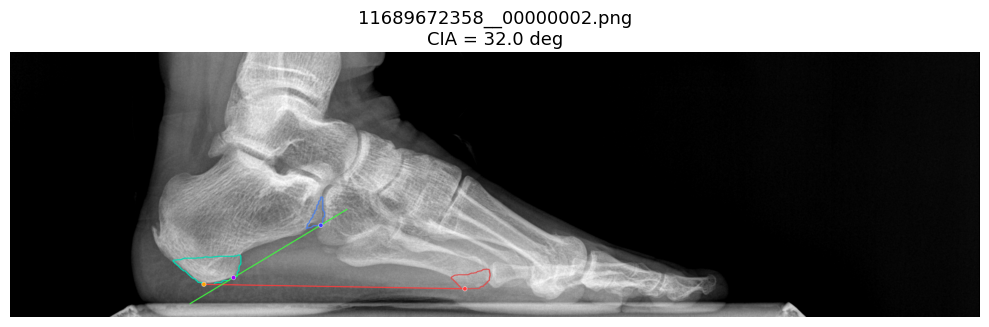

13346210842.png                                     CIA = 21.0 deg


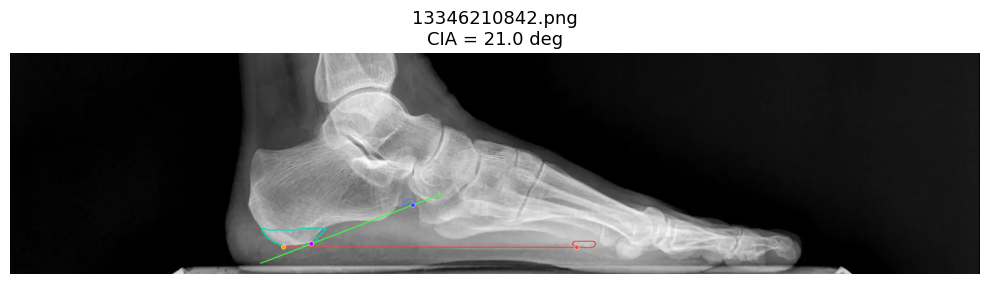

13483430578 gülşan topçu 1.png                   CIA = 20.4 deg


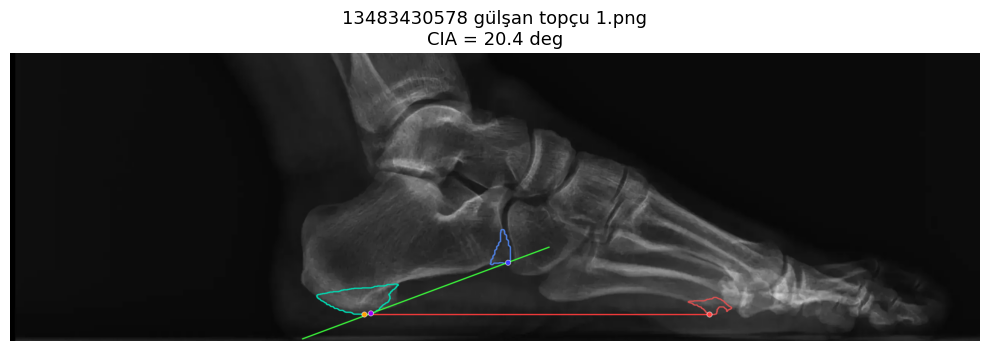

14669502744 ayşe özzsoy -1.png                    CIA = 15.6 deg


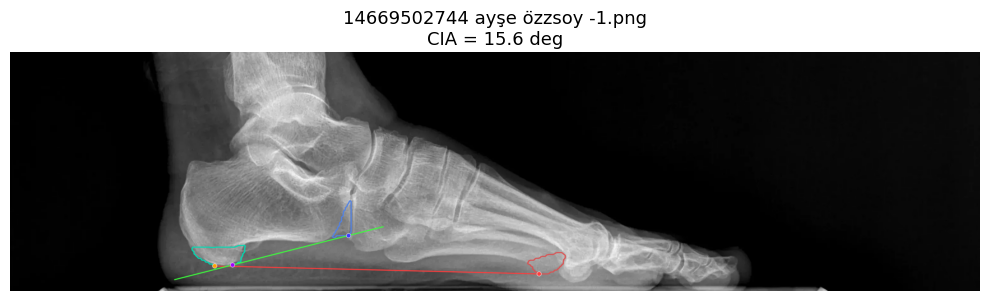

16591994116_1.png                                   CIA = 19.2 deg


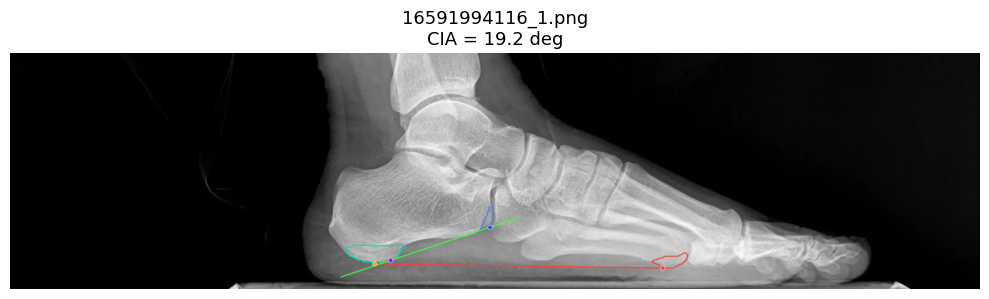

16591994116_2.png                                   CIA = 19.2 deg


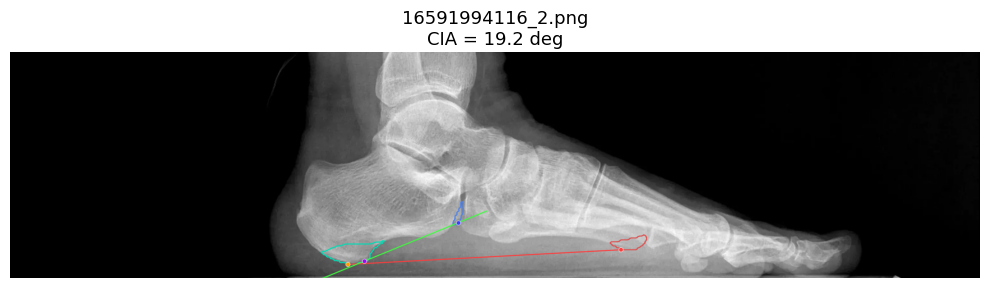


--- Summary ---
  11689672358__00000002.png                           31.97 deg
  13346210842.png                                     20.96 deg
  13483430578 gülşan topçu 1.png                   20.37 deg
  14669502744 ayşe özzsoy -1.png                    15.61 deg
  16591994116_1.png                                   19.22 deg
  16591994116_2.png                                   19.18 deg

  n=6  mean=21.2  std=5.1  min=15.6  max=32.0


In [11]:
# =============================================================
# RUN INFERENCE & VISUALIZE  [INFER]
# =============================================================
MASK_COLORS = {
    'calcaneus_inferior': (  0, 220, 180),
    'metatarsal_5':       (220,  80,  80),
    'calcaneocuboid':  ( 80, 130, 230),
}
PT_COLORS = [
    (255,  60,  60),   # P1 - red
    (255, 160,   0),   # P2 - orange
    (160,   0, 255),   # P3 - purple
    ( 60,  60, 255),   # P4 - blue
]

results = []

for img_path in TEST_PATHS:
    cia, masks, img_gray, P1, P2, P3, P4 = full_inference(model, img_path)

    cia_str = f'{cia:.1f} deg' if cia is not None else 'N/A'
    results.append({'file': os.path.basename(img_path), 'CIA': cia})
    print(f'{os.path.basename(img_path):50s}  CIA = {cia_str}')

    # Build overlay
    ov = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
    for lbl, clr in MASK_COLORS.items():
        if masks.get(lbl) is not None:
            cnts, _ = cv2.findContours((masks[lbl] > 0).astype(np.uint8),
                                       cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            cv2.drawContours(ov, cnts, -1, clr, 2, cv2.LINE_AA)

    if P1 is not None and P2 is not None:
        cv2.line(ov, tuple(map(int, P1)), tuple(map(int, P2)),
                 (255, 60, 60), 2, cv2.LINE_AA)
    if P3 is not None and P4 is not None:
        d = np.array(P3, np.float64) - np.array(P4, np.float64)
        cv2.line(ov,
                 tuple(map(int, np.array(P4) - d * 0.3)),
                 tuple(map(int, np.array(P4) + d * 1.5)),
                 (60, 255, 60), 2, cv2.LINE_AA)

    for pt, clr in zip([P1, P2, P3, P4], PT_COLORS):
        if pt is not None:
            cv2.circle(ov, tuple(map(int, pt)), 6, clr,          -1, cv2.LINE_AA)
            cv2.circle(ov, tuple(map(int, pt)), 7, (255,255,255), 1, cv2.LINE_AA)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(ov)
    ax.set_title(f'{os.path.basename(img_path)}\nCIA = {cia_str}', fontsize=13)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# Summary table
print('\n--- Summary ---')
cia_vals = [r['CIA'] for r in results if r['CIA'] is not None]
for r in results:
    val = f"{r['CIA']:.2f} deg" if r['CIA'] is not None else 'N/A'
    print(f"  {r['file']:50s}  {val}")
if cia_vals:
    print(f'\n  n={len(cia_vals)}  mean={np.mean(cia_vals):.1f}  '
          f'std={np.std(cia_vals):.1f}  '
          f'min={np.min(cia_vals):.1f}  max={np.max(cia_vals):.1f}')

In [12]:
# =============================================================
# DOWNLOAD RESULTS CSV  [INFER]
# =============================================================
import csv
from google.colab import files

csv_path = '/content/cia_results.csv'
with open(csv_path, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['filename', 'CIA_degrees'])
    for r in results:
        w.writerow([r['file'], f"{r['CIA']:.2f}" if r['CIA'] is not None else 'N/A'])

print(f'Results saved: {csv_path}')
files.download(csv_path)

Results saved: /content/cia_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>